In [525]:
import torch 
import torch.nn.functional as F
import matplotlib as plt 
import matplotlib.pyplot as plt
%matplotlib inline

# Loading Data set

In [154]:
words = open('names.txt','r').read().splitlines()       #open the txt file get a list of the names
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [155]:
min(len(w) for w in words)      #shortest word = 2
max(len(w) for w in words)      #longest words = 15

15

# Biagram language model 

workding with 2 characters at a time

decompose a word by character

In [507]:
for w in words[:1]:
    chs=['.']+list(w)+['.']                         #list because emma is a string and we want the list of character
    for ch1, ch2 in zip(chs,chs[1:]):               #zip = elegant way to decompose a string by characters
        print(ch1,ch2)
        

. e
e m
m m
m a
a .


need to count how often combination of character

In [293]:
b = {}                                              # need a dictionary to keep track 
for w in words:                                     # words for all words, words[:3] for the first 3
    chs=['.']+list(w)+['.']                         #list because emma is a string and we want the list of character
    for ch1, ch2 in zip(chs,chs[1:]):
        biagram = (ch1,ch2)     
        b[biagram]=b.get(biagram,0)+1               #biagram is a tuple of ch1 and ch2
        #print(ch1,ch2)                             #can or not print the pair of character    

In [153]:
b

{('.', 'e'): 1531,
 ('e', 'm'): 769,
 ('m', 'm'): 168,
 ('m', 'a'): 2590,
 ('a', '.'): 6640,
 ('.', 'o'): 394,
 ('o', 'l'): 619,
 ('l', 'i'): 2480,
 ('i', 'v'): 269,
 ('v', 'i'): 911,
 ('i', 'a'): 2445,
 ('.', 'a'): 4410,
 ('a', 'v'): 834,
 ('v', 'a'): 642,
 ('.', 'i'): 591,
 ('i', 's'): 1316,
 ('s', 'a'): 1201,
 ('a', 'b'): 541,
 ('b', 'e'): 655,
 ('e', 'l'): 3248,
 ('l', 'l'): 1345,
 ('l', 'a'): 2623,
 ('.', 's'): 2055,
 ('s', 'o'): 531,
 ('o', 'p'): 95,
 ('p', 'h'): 204,
 ('h', 'i'): 729,
 ('.', 'c'): 1542,
 ('c', 'h'): 664,
 ('h', 'a'): 2244,
 ('a', 'r'): 3264,
 ('r', 'l'): 413,
 ('l', 'o'): 692,
 ('o', 't'): 118,
 ('t', 't'): 374,
 ('t', 'e'): 716,
 ('e', '.'): 3983,
 ('.', 'm'): 2538,
 ('m', 'i'): 1256,
 ('a', 'm'): 1634,
 ('m', 'e'): 818,
 ('.', 'h'): 874,
 ('r', 'p'): 14,
 ('p', 'e'): 197,
 ('e', 'r'): 1958,
 ('r', '.'): 1377,
 ('e', 'v'): 463,
 ('v', 'e'): 568,
 ('l', 'y'): 1588,
 ('y', 'n'): 1826,
 ('n', '.'): 6763,
 ('b', 'i'): 217,
 ('i', 'g'): 428,
 ('g', 'a'): 330,
 ('a',

need to create the index to ease the counting

In [294]:

D=sorted(list(set(''.join(words))))                     #get all character possible from the list of name and sort them 
#D[0]='.'
vocab_size = len(D)


In [295]:
stoi = {s:i+1 for i,s in enumerate(D)}
stoi['.']=0
itos = {i:s for s,i in stoi.items()}


In [178]:
itos

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

Create a matrix 27x27 with the characters and value = number of time the combination happens

In [ ]:
N = torch.zeros((27,27), dtype = torch.int32)

torch.int32

count in the matrix

In [ ]:
N = torch.zeros((27,27), dtype = torch.int32)       #need to initialise N at 0 to avoid adding more when running

for w in words:                                     # words for all words, words[:3] for the first 3
    chs=['.']+list(w)+['.']                         #list because emma is a string and we want the list of character
    for ch1, ch2 in zip(chs,chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        N[ix1,ix2]+=1 

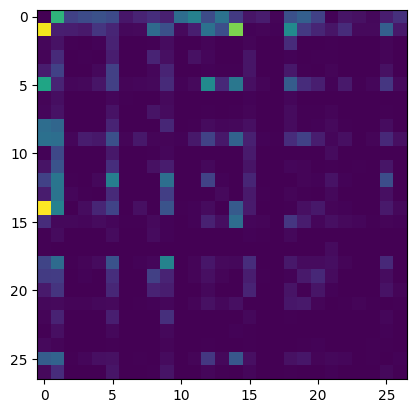

In [346]:
plt.imshow(N)

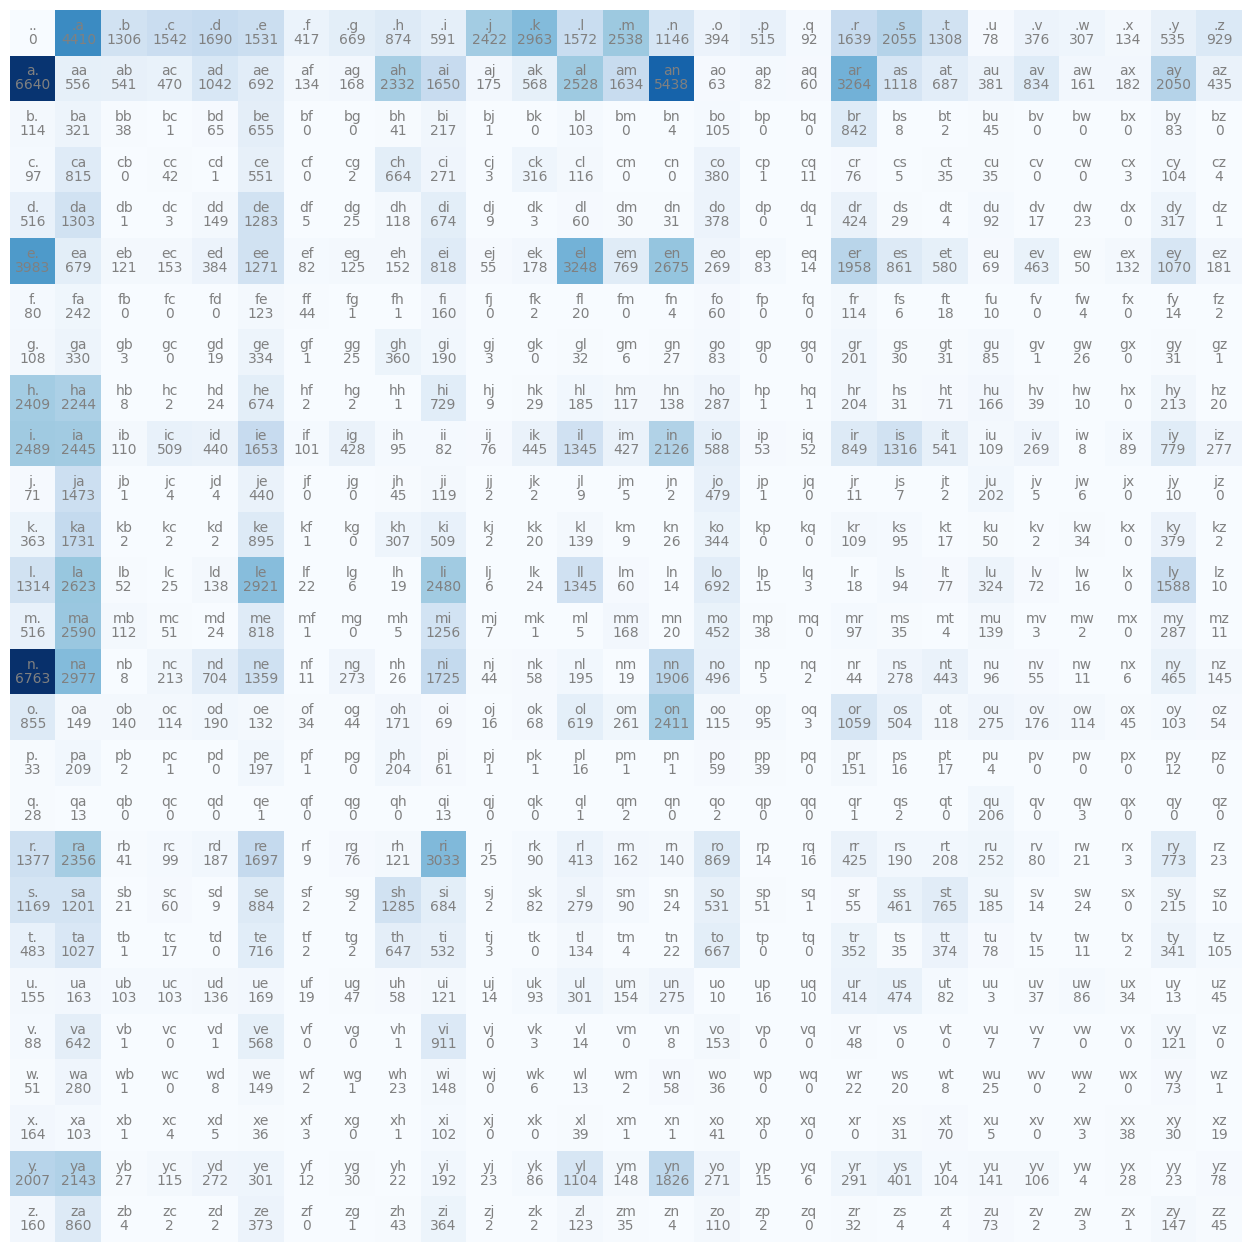

In [365]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27 ):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

we have the number, now we want to sample from it using the probability of appearance, starting with the first line

In [325]:
p = N[0].float()                    #first line
p = p / p.sum()                     # transforming to proba for each letter = number of appearance / total of the line
p                                   # this is the probability 

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

to sample from it we need multinomial from pytorch, and lets use a generator for getting things deterministic 

In [326]:
g = torch.Generator().manual_seed(2147483647)
idx=torch.multinomial(p,1,replacement=True,generator=g).item()
sdx=itos[idx]
sdx

'c'

lets build the loop to continue our name sampling 

In [327]:
g = torch.Generator().manual_seed(2147483647)
idx=0

out=[]                                                                      #creating a list to keep track 

while True:
    p = N[idx].float()                   
    p = p / p.sum()  
    idx=torch.multinomial(p,1,replacement=True,generator=g).item()
    out.append(itos[idx])                                                   # append the list for each new character
    if idx==0:
        break 

print(''.join(out))                                                         #print the joined list of character


cexze.


for efficiency we want to create a matix P that have all the probability : N --> P:

for each row in N
each column = column / sum of the row 

In [ ]:
P = torch.zeros((27,27))

for i in range(len(N)):
    for j in range(len(N[i])):
        P[i][j]=N[i][j]/row_sum[i]


In [353]:
P[1,1]

tensor(0.0164)


or lets try with torch.sum()

In [ ]:
 P1=N/torch.sum(N,dim=1, keepdim=True)               # need to keep keep dim True. can also add (N+1) instead of N / torch.... for model smoothing

In [379]:
P1[1,1]                                        #same results here so it confirm we are good

tensor(0.0164)

In [377]:
P1

tensor([[0.0000e+00, 1.3767e-01, 4.0770e-02, 4.8138e-02, 5.2758e-02, 4.7794e-02,
         1.3018e-02, 2.0885e-02, 2.7284e-02, 1.8450e-02, 7.5610e-02, 9.2498e-02,
         4.9074e-02, 7.9231e-02, 3.5776e-02, 1.2300e-02, 1.6077e-02, 2.8720e-03,
         5.1166e-02, 6.4153e-02, 4.0833e-02, 2.4350e-03, 1.1738e-02, 9.5839e-03,
         4.1832e-03, 1.6702e-02, 2.9001e-02],
        [1.9596e-01, 1.6408e-02, 1.5966e-02, 1.3870e-02, 3.0751e-02, 2.0422e-02,
         3.9546e-03, 4.9579e-03, 6.8821e-02, 4.8694e-02, 5.1645e-03, 1.6763e-02,
         7.4605e-02, 4.8222e-02, 1.6048e-01, 1.8592e-03, 2.4199e-03, 1.7707e-03,
         9.6326e-02, 3.2994e-02, 2.0274e-02, 1.1244e-02, 2.4613e-02, 4.7514e-03,
         5.3711e-03, 6.0499e-02, 1.2838e-02],
        [4.3100e-02, 1.2136e-01, 1.4367e-02, 3.7807e-04, 2.4575e-02, 2.4764e-01,
         0.0000e+00, 0.0000e+00, 1.5501e-02, 8.2042e-02, 3.7807e-04, 0.0000e+00,
         3.8941e-02, 0.0000e+00, 1.5123e-03, 3.9698e-02, 0.0000e+00, 0.0000e+00,
         3.1834e-

Let's sample but now using the Probability Matrix

In [ ]:
g = torch.Generator().manual_seed(2147483647)


for i in range(5):
    out=[]                                                                   #creating a list to keep track 
    idx=0
    while True:
        p=P1[idx]                                                           # just need to call the proba from the matrix at the current character 
        idx=torch.multinomial(p,1,replacement=True,generator=g).item()      #multinomial will return the outcome given the probability matrix
        out.append(itos[idx])                                               # append the list for each new character
        if idx==0:
            break 

    print(''.join(out)) 

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


now we need to evaluate the model quality, 

we will use the average negative log likelyhood as a measure of quality 
lets build it for a few words

In [414]:
n=0
ll=0
nll=0.0

for w in words:
    chs=['.']+list(w)+['.']                         #list because emma is a string and we want the list of character
    for ch1, ch2 in zip(chs,chs[1:]):               #zip = elegant way to decompose a string by characters
        ix1=stoi[ch1]                               #need to transform character to int so we could reference to the Matrix
        ix2=stoi[ch2]
        prob=P1[ix1,ix2]                            # Proba
        logprob=torch.log(prob)                     # log proba
        ll+=logprob                                 # log likelyhood = summ of log prob
        nll=-ll                                     # negatice ll
        n+=1                                        # to keep track of the count so we can compute the average as a final metric of quality 
        #print(f'{ch1}{ch2} : { prob:.4f} --> {logprob:.4f}')

print(f'{nll}')
print(f'{nll/n}')
        

559891.75
2.454094171524048


the objective is to minimize the negative log likelyhood (or the average)

Let's now build an MLP for the same objective
first need to create training and testing data set

In [489]:
xs, ys = [] , []

for w in words[:1]:
    chs=['.']+list(w)+['.']                         #list because emma is a string and we want the list of character
    for ch1, ch2 in zip(chs,chs[1:]):               #zip = elegant way to decompose a string by characters
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs=torch.tensor(xs)                                  # need to keep integer so far to send to do One Hotting
ys=torch.tensor(ys)

In [505]:
xs

tensor([ 0,  5, 13, 13,  1])

need to encode with One Hot to be able to push to the neurons

In [434]:
import torch.nn.functional as F


In [534]:
xenc=F.one_hot(xs, 27).float()                            #as we want to push to a NN, we need float 
xenc.shape

torch.Size([5, 27])

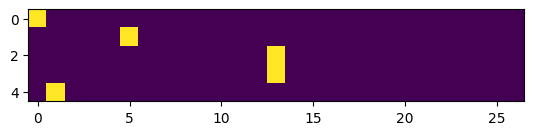

In [475]:
plt.imshow(xenc)

now that we have have what to feed the NN, we can create the NN structure

In [461]:
W=torch.randn(27,27)                         # initialize the random Weight Matrix 
W

tensor([[-8.0324e-01, -2.1432e-01, -1.7316e+00,  2.3846e-01,  6.8882e-01,
          7.1187e-02,  6.2444e-01, -6.0304e-01,  1.5127e+00, -1.1824e+00,
         -2.2664e-01, -3.9155e-01,  1.3811e+00, -2.5985e-01,  4.0181e-01,
          2.2546e+00,  4.6915e-01, -3.1880e-02, -5.9496e-02,  8.2798e-01,
          1.2392e+00, -4.0024e-01, -3.3443e-01,  4.2475e-02, -1.4225e+00,
         -5.6744e-02,  1.4994e-01],
        [ 1.0836e+00, -6.1933e-01,  3.9193e-02, -1.7906e+00,  1.5334e-01,
          6.0600e-01,  5.5624e-01,  1.0974e-01, -9.4498e-01, -9.1097e-01,
          9.6908e-01,  8.1657e-01,  9.8285e-01,  5.8302e-01, -5.5941e-01,
         -1.2729e+00, -1.3501e-01,  1.4065e+00, -1.7465e+00, -2.8383e-01,
         -1.2662e+00, -3.8141e-01,  1.5427e+00, -1.2117e+00,  9.9382e-01,
          1.5576e+00, -1.3496e+00],
        [-3.7299e-01,  7.2209e-01,  1.7743e-01,  1.2072e+00, -5.8715e-01,
         -1.4068e-01,  1.2503e+00,  1.3619e+00, -4.7381e-02, -7.9442e-01,
         -1.5483e+00, -1.8161e+00,  1.35

Similarly we need to keep track of the counts (or log-counts), the equivalent of matrix N as well as the proba Matrix (before training)

In [603]:
# Forward Pass

logits = xenc @ W                                      # log-counts

#SoftMax

counts = (xenc @ W).exp()                              # equivalent of N, represent the counts - need positive count so we exponentiate 
probs = counts / counts.sum(1, keepdim=True)            # normalise by line = proba for the next character 
probs

#probs[1].sum() --> return 1   --> ok  

tensor([[0.0101, 0.0182, 0.0040, 0.0286, 0.0449, 0.0242, 0.0421, 0.0123, 0.1025,
         0.0069, 0.0180, 0.0153, 0.0898, 0.0174, 0.0337, 0.2151, 0.0361, 0.0219,
         0.0213, 0.0517, 0.0779, 0.0151, 0.0162, 0.0236, 0.0054, 0.0213, 0.0262],
        [0.0013, 0.0394, 0.0204, 0.0076, 0.0232, 0.0163, 0.0179, 0.0181, 0.0174,
         0.0120, 0.0309, 0.0353, 0.0330, 0.0165, 0.0749, 0.0745, 0.2411, 0.0581,
         0.0335, 0.0209, 0.0309, 0.0144, 0.0412, 0.0116, 0.0106, 0.0554, 0.0438],
        [0.0119, 0.0350, 0.1912, 0.0107, 0.0330, 0.0294, 0.0208, 0.0701, 0.0226,
         0.0530, 0.0195, 0.0068, 0.0284, 0.0878, 0.0202, 0.0122, 0.0096, 0.0634,
         0.0178, 0.0846, 0.0054, 0.0307, 0.0326, 0.0162, 0.0222, 0.0340, 0.0310],
        [0.0119, 0.0350, 0.1912, 0.0107, 0.0330, 0.0294, 0.0208, 0.0701, 0.0226,
         0.0530, 0.0195, 0.0068, 0.0284, 0.0878, 0.0202, 0.0122, 0.0096, 0.0634,
         0.0178, 0.0846, 0.0054, 0.0307, 0.0326, 0.0162, 0.0222, 0.0340, 0.0310],
        [0.0719, 0.0131,

lets create some line to visualise the current quality as of now :

In [506]:

nlls=torch.zeros(5)
for i in range(5):
    x = xs[i].item()                #created earlier for "emma" only
    y = ys[i].item()                # .item() as xs and ys are tensor
    print(f'----------')
    print(f'Biagram example {i+1}: x : {x} : {itos[x]}    and    y : {y} : {itos[y]}')
    print(f'The probability matrix for the input {itos[x]} : {probs[i]}')
    print(f'The probability to get the desired output {itos[y]} : {probs[i][y]}')
    p = probs[i,y]
    logp = torch.log(p)
    print(f'The log likely hood is {logp}')
    NLL = -logp
    print(f'Negative Log Likelyhood : {NLL}')

print(f'----------')
print(f'average Negative Loglikelyhood : {NLL.mean()}')


----------
Biagram example 1: x : 0 : .    and    y : 5 : e
The probability matrix for the input . : tensor([0.0101, 0.0182, 0.0040, 0.0286, 0.0449, 0.0242, 0.0421, 0.0123, 0.1025,
        0.0069, 0.0180, 0.0153, 0.0898, 0.0174, 0.0337, 0.2151, 0.0361, 0.0219,
        0.0213, 0.0517, 0.0779, 0.0151, 0.0162, 0.0236, 0.0054, 0.0213, 0.0262])
The probability to get the desired output e : 0.024236658588051796
The log likely hood is -3.719888925552368
Negative Log Likelyhood : 3.719888925552368
----------
Biagram example 2: x : 5 : e    and    y : 13 : m
The probability matrix for the input e : tensor([0.0013, 0.0394, 0.0204, 0.0076, 0.0232, 0.0163, 0.0179, 0.0181, 0.0174,
        0.0120, 0.0309, 0.0353, 0.0330, 0.0165, 0.0749, 0.0745, 0.2411, 0.0581,
        0.0335, 0.0209, 0.0309, 0.0144, 0.0412, 0.0116, 0.0106, 0.0554, 0.0438])
The probability to get the desired output m : 0.01649441011250019
The log likely hood is -4.104733943939209
Negative Log Likelyhood : 4.104733943939209
----------

## Optimization 

now we want to train the model, and tweak the W parameter with gradient descent : using the loss function 

In [510]:
xs

tensor([ 0,  5, 13, 13,  1])

In [511]:
ys

tensor([ 5, 13, 13,  1,  0])

In [529]:
#randomly initiate 27 neurons
g=torch.Generator().manual_seed(2147483647)
W1=torch.randn((27,27),generator=g, requires_grad=True)

In [531]:
W1.shape

torch.Size([27, 27])

In [556]:
# Forward Pass : 

xenc1=F.one_hot(xs,num_classes=27).float()                # xenc = input encoded     
logits = xenc1 @ W1                                     #  --> log-counts
counts = (xenc1 @ W1).exp()                              # equivalent of N, represent the counts - need positive count so we exponentiate 
probs = counts / counts.sum(1, keepdim=True)            # normalise by line = proba for the next character 
loss= -probs[torch.arange(5),ys].log().mean()


In [557]:
print(loss.item())

3.7291626930236816


In [554]:
#backward pass
W1.grad = None
loss.backward()

In [555]:
W1.data += -0.1 * W1.grad

### From end to end : Optimization

##### Create Data Set

In [575]:
xs, ys = [] , []

for w in words:
    chs=['.']+list(w)+['.']                         #list because emma is a string and we want the list of character
    for ch1, ch2 in zip(chs,chs[1:]):               #zip = elegant way to decompose a string by characters
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)                                  # need to keep integer so far to send to do One Hotting
ys = torch.tensor(ys)

num = xs.nelement()
print(num)

g = torch.Generator().manual_seed(2147483647)
W2 = torch.randn((27,27),generator=g, requires_grad=True)


228146


#### Optimization : Gradient Descend

In [622]:
xenc2 = F.one_hot(xs,num_classes=27).float()

for K in range(1000): 
    
    #Forward pass
    logits2 = xenc2 @ W2
    counts2 = logits2.exp()
    probs2 = counts2/counts2.sum(1, keepdim=True)
    loss2 = -probs2[torch.arange(num),ys].log().mean()
    print(loss2.item())

    #backward pass
    W2.grad = None
    loss2.backward()

    #update W2 weights
    W2.data += -0.1*W2.grad


2.480851173400879
2.4808504581451416
2.4808497428894043
2.480848789215088
2.4808478355407715
2.480846881866455
2.4808461666107178
2.4808452129364014
2.480844259262085
2.4808433055877686
2.4808428287506104
2.480841875076294
2.4808409214019775
2.4808402061462402
2.4808390140533447
2.4808385372161865
2.48083758354187
2.480836868286133
2.4808356761932373
2.4808349609375
2.4808340072631836
2.4808332920074463
2.48083233833313
2.4808316230773926
2.4808309078216553
2.480829954147339
2.4808290004730225
2.480828046798706
2.4808273315429688
2.4808263778686523
2.480825424194336
2.4808244705200195
2.4808239936828613
2.480823040008545
2.4808223247528076
2.480821132659912
2.480820417404175
2.4808194637298584
2.480818748474121
2.480818033218384
2.4808170795440674
2.48081636428833
2.4808154106140137
2.4808144569396973
2.480813503265381
2.4808127880096436
2.480811834335327
2.48081111907959
2.4808099269866943
2.480809211730957
2.4808082580566406
2.4808075428009033
2.480806589126587
2.4808058738708496
2.4

#### Sampling

In [623]:
probs2.shape

torch.Size([228146, 27])

In [624]:
P_nn = W2.exp() / W2.exp().sum(1, keepdim=True)


In [643]:
for i in range(5):
    out=[]                                                                  #creating a list to keep track 
    idx=0
    while True:
        p = P_nn[idx]                                                      # just need to call the proba from the matrix at the current character 
        idx=torch.multinomial(p,1,replacement=True).item()                  #multinomial will return the outcome given the probability matrix
        out.append(itos[idx])                                               # append the list for each new character
        if idx==0:
            break 

    print(''.join(out)) 

mee.
abr.
tavadee.
hon.
eda.


# MLP Makemore 2

we will now build a more sophisticated model : MLP 
and get more context than just the previous character

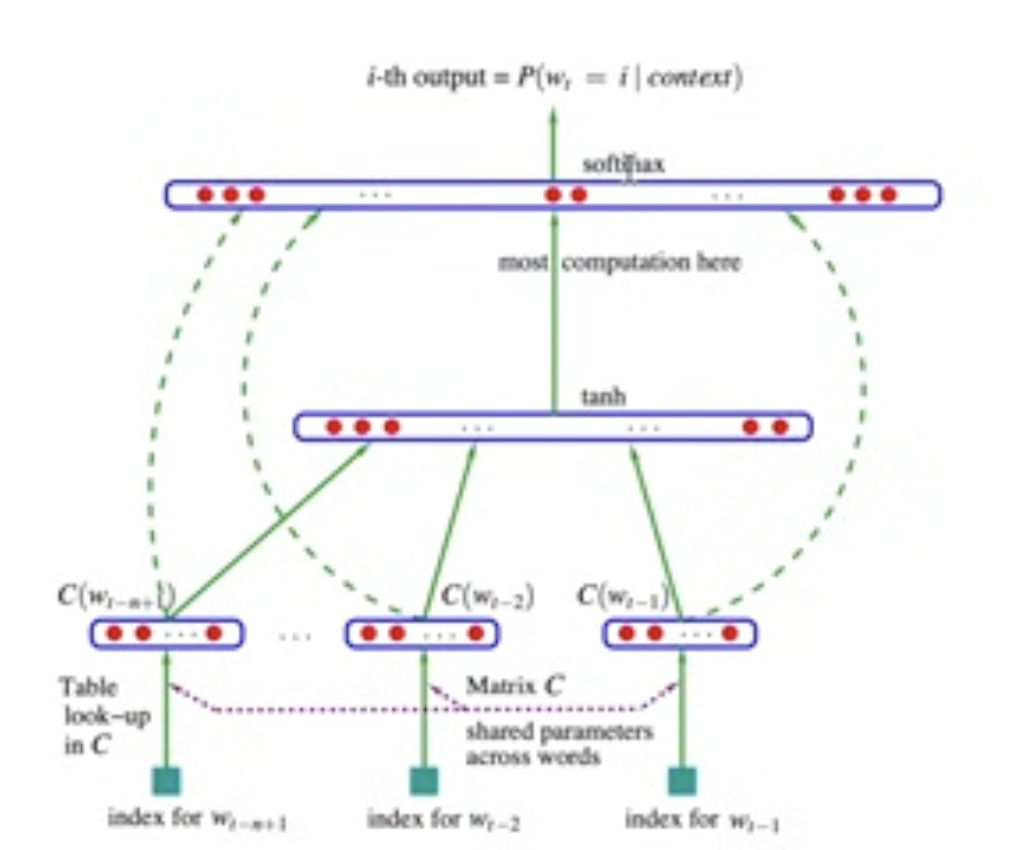

there is C as activation layer /
hidden layer /
output layer 